# Unemployment Analysis in India (with COVID-19 Impact)
### CodeAlpha Data Science Internship — Task 2

**Objective:** Analyze unemployment rate data across Indian states, clean and explore it,
visualize trends, study the impact of COVID-19 on unemployment, identify seasonal
patterns, and present insights useful for economic/social policy making.

**Datasets used:**
1. `Unemployment_in_India.xlsx` — state-wise unemployment data (Rural/Urban split), May 2019 – Jun 2020
2. `Unemployment_Rate_upto_11_2020.xlsx` — state-wise unemployment data with geographic coordinates and region grouping, Jan 2020 – Oct 2020


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

%matplotlib inline


## 2. Load the Data

In [2]:
df1 = pd.read_excel("data/Unemployment_in_India.xlsx")
df2 = pd.read_excel("data/Unemployment_Rate_upto_11_2020.xlsx")

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)
df1.head()


Dataset 1 shape: (754, 7)
Dataset 2 shape: (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df2.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region2,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 3. Data Cleaning

Both files have column names with leading/trailing whitespace, some missing rows,
and date columns stored as text. We standardize column names, parse dates, drop
fully-empty rows, and merge the two datasets into a single clean table for analysis.


In [4]:
def clean(df):
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    # drop rows that are entirely empty (present in dataset 1)
    df = df.dropna(how='all')
    df = df.dropna(subset=['Region', 'Date'])
    # strip whitespace from string columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
    df['Region'] = df['Region'].str.strip()
    df.rename(columns={
        'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
        'Estimated Employed': 'Employed',
        'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
    }, inplace=True)
    df['Month'] = df['Date'].dt.month
    df['Month_name'] = df['Date'].dt.strftime('%b')
    df['Year'] = df['Date'].dt.year
    return df

df1_clean = clean(df1)
df2_clean = clean(df2)

print("Dataset 1 after cleaning:", df1_clean.shape)
print("Dataset 2 after cleaning:", df2_clean.shape)
df1_clean.isnull().sum()


Dataset 1 after cleaning: (740, 10)
Dataset 2 after cleaning: (267, 12)


/tmp/ipykernel_603/694265975.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:
/tmp/ipykernel_603/694265975.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for deta

Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
Month                        0
Month_name                   0
Year                         0
dtype: int64

In [5]:
# Dataset 1 has an Area column (Rural/Urban); Dataset 2 does not (state-level overall figures)
# but has Region2 (zone) and coordinates. We keep them as complementary datasets and
# also build one combined dataset of common columns for a fuller time range (2019-2020).

common_cols = ['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed',
               'Labour_Participation_Rate', 'Month', 'Month_name', 'Year']

combined = pd.concat([df1_clean[common_cols], df2_clean[common_cols]], ignore_index=True)
combined = combined.drop_duplicates(subset=['Region', 'Date'])
combined = combined.sort_values(['Region', 'Date']).reset_index(drop=True)
print("Combined dataset shape:", combined.shape)
print("Date range:", combined['Date'].min(), "to", combined['Date'].max())
combined.head()


Combined dataset shape: (494, 9)
Date range: 2019-05-31 00:00:00 to 2020-10-31 00:00:00


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Month,Month_name,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,5,May,2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,6,Jun,2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,7,Jul,2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,8,Aug,2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,9,Sep,2019


## 4. Descriptive Statistics

In [6]:
combined[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].describe()


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,494.000000,4.940000e+02,494.000000
mean,10.294413,1.060002e+07,43.737976
std,9.697573,1.097248e+07,8.398445
min,0.000000,4.942000e+04,13.330000
25%,4.070000,1.912406e+06,38.607500
50%,7.045000,7.526842e+06,41.985000
75%,13.805000,1.524533e+07,46.847500
max,75.000000,5.653952e+07,72.570000


In [7]:
print("Number of unique states/UTs:", combined['Region'].nunique())
print(sorted(combined['Region'].unique()))


Number of unique states/UTs: 28
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


## 5. National Unemployment Trend Over Time

We plot the average unemployment rate across all regions for each month to see the
overall trend, including the sharp spike during the COVID-19 lockdown (March–May 2020).


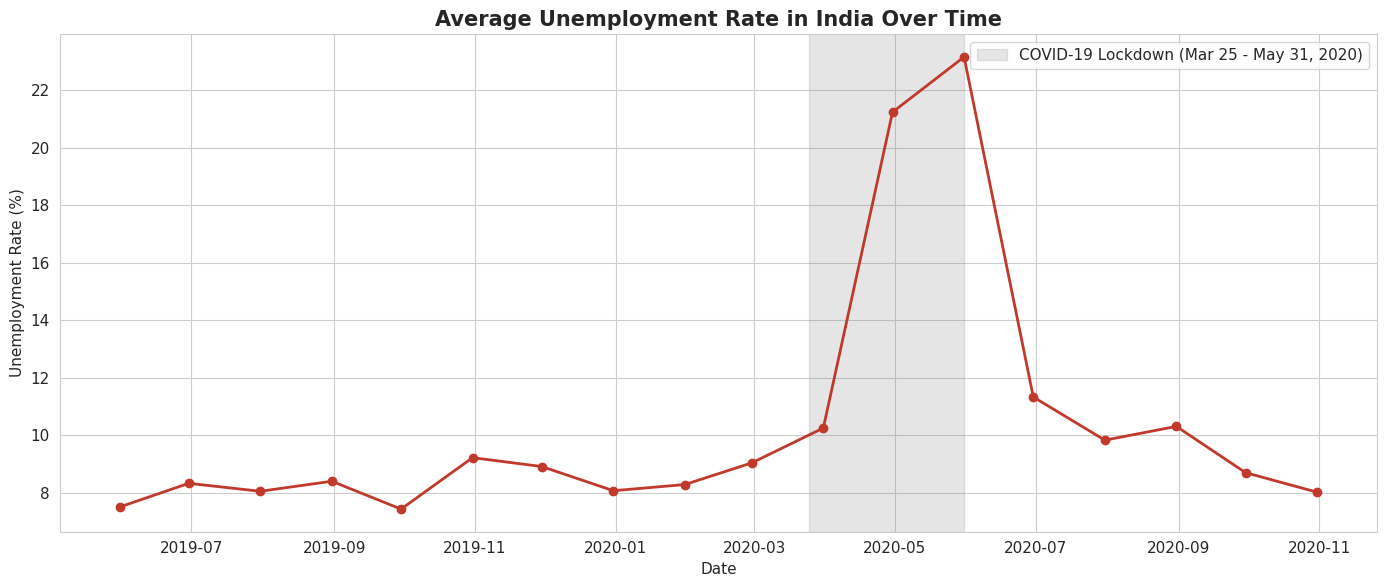

In [8]:
monthly_avg = combined.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14,6))
plt.plot(monthly_avg['Date'], monthly_avg['Unemployment_Rate'], marker='o', color='#c0392b', linewidth=2)
plt.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-05-31'), color='grey', alpha=0.2, label='COVID-19 Lockdown (Mar 25 - May 31, 2020)')
plt.title('Average Unemployment Rate in India Over Time', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('images/01_national_trend.png', dpi=150)
plt.show()


## 6. Impact of COVID-19 on Unemployment

We compare the average unemployment rate **before** the lockdown (up to Feb 2020) versus
**during/after** the lockdown (Mar 2020 onward) to quantify the pandemic's impact.


In [9]:
pre_covid = combined[combined['Date'] < '2020-03-01']['Unemployment_Rate'].mean()
during_after_covid = combined[combined['Date'] >= '2020-03-01']['Unemployment_Rate'].mean()
peak_row = combined.loc[combined.groupby('Date')['Unemployment_Rate'].transform('mean').idxmax()] if False else monthly_avg.loc[monthly_avg['Unemployment_Rate'].idxmax()]

print(f"Average unemployment rate BEFORE COVID-19 (pre Mar 2020): {pre_covid:.2f}%")
print(f"Average unemployment rate DURING/AFTER COVID-19 (Mar 2020 onward): {during_after_covid:.2f}%")
print(f"Increase: {during_after_covid - pre_covid:.2f} percentage points ({(during_after_covid/pre_covid - 1)*100:.1f}% relative increase)")
print(f"Peak month: {peak_row['Date'].strftime('%B %Y')} with average unemployment rate of {peak_row['Unemployment_Rate']:.2f}%")


Average unemployment rate BEFORE COVID-19 (pre Mar 2020): 8.33%
Average unemployment rate DURING/AFTER COVID-19 (Mar 2020 onward): 12.80%
Increase: 4.47 percentage points (53.6% relative increase)
Peak month: May 2020 with average unemployment rate of 23.15%


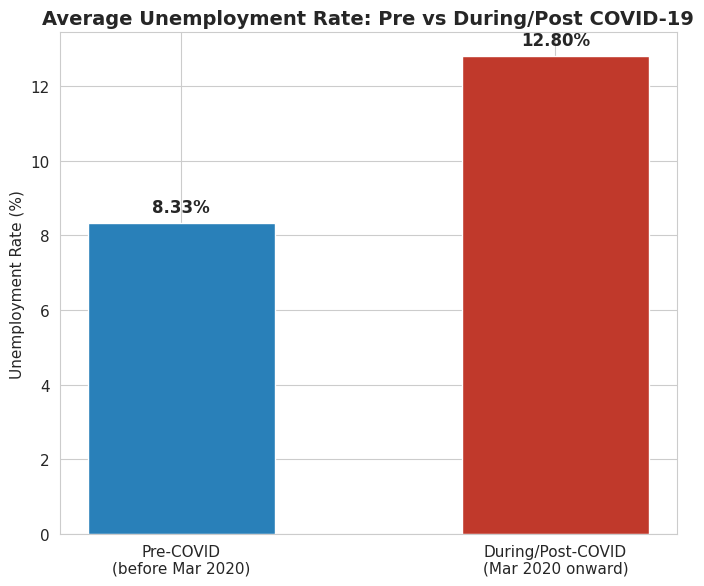

In [10]:
labels = ['Pre-COVID\n(before Mar 2020)', 'During/Post-COVID\n(Mar 2020 onward)']
values = [pre_covid, during_after_covid]

plt.figure(figsize=(7,6))
bars = plt.bar(labels, values, color=['#2980b9', '#c0392b'], width=0.5)
for bar, v in zip(bars, values):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=12)
plt.title('Average Unemployment Rate: Pre vs During/Post COVID-19', fontsize=14, fontweight='bold')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('images/02_covid_before_after.png', dpi=150)
plt.show()


## 7. Rural vs Urban Impact (Dataset 1)

Dataset 1 breaks unemployment down by Rural and Urban areas, letting us see whether
the pandemic affected cities or villages more severely.


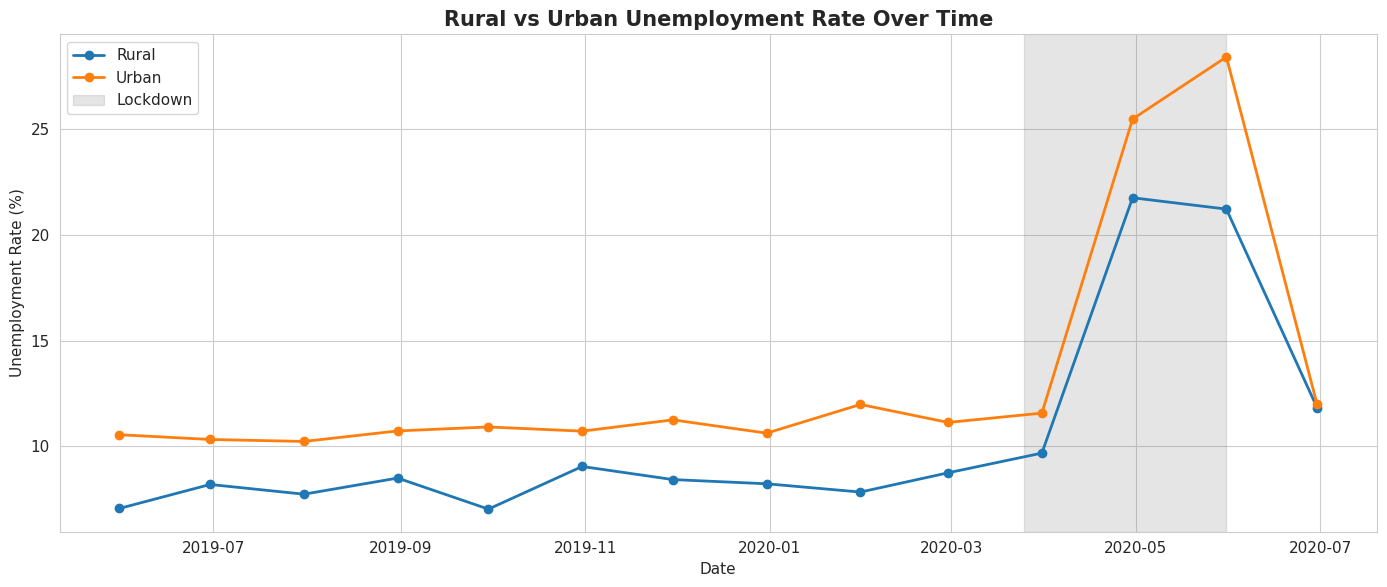

In [11]:
area_trend = df1_clean.groupby(['Date', 'Area'])['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14,6))
for area, grp in area_trend.groupby('Area'):
    plt.plot(grp['Date'], grp['Unemployment_Rate'], marker='o', label=area, linewidth=2)
plt.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-05-31'), color='grey', alpha=0.2, label='Lockdown')
plt.title('Rural vs Urban Unemployment Rate Over Time', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('images/03_rural_vs_urban.png', dpi=150)
plt.show()


In [12]:
rural_pre = df1_clean[(df1_clean['Area']=='Rural') & (df1_clean['Date']<'2020-03-01')]['Unemployment_Rate'].mean()
rural_post = df1_clean[(df1_clean['Area']=='Rural') & (df1_clean['Date']>='2020-03-01')]['Unemployment_Rate'].mean()
urban_pre = df1_clean[(df1_clean['Area']=='Urban') & (df1_clean['Date']<'2020-03-01')]['Unemployment_Rate'].mean()
urban_post = df1_clean[(df1_clean['Area']=='Urban') & (df1_clean['Date']>='2020-03-01')]['Unemployment_Rate'].mean()

print(f"Rural — Pre-COVID: {rural_pre:.2f}%  |  During/Post-COVID: {rural_post:.2f}%  |  Increase: {rural_post-rural_pre:.2f} pts")
print(f"Urban — Pre-COVID: {urban_pre:.2f}%  |  During/Post-COVID: {urban_post:.2f}%  |  Increase: {urban_post-urban_pre:.2f} pts")


Rural — Pre-COVID: 8.09%  |  During/Post-COVID: 16.18%  |  Increase: 8.09 pts
Urban — Pre-COVID: 10.84%  |  During/Post-COVID: 19.28%  |  Increase: 8.43 pts


## 8. State-Wise Unemployment Comparison

Which states were hit hardest during the COVID-19 period? We compare the peak
(April–May 2020) unemployment rate by state.


/tmp/ipykernel_603/1446925315.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_peak.values, y=state_peak.index, palette='Reds_r')


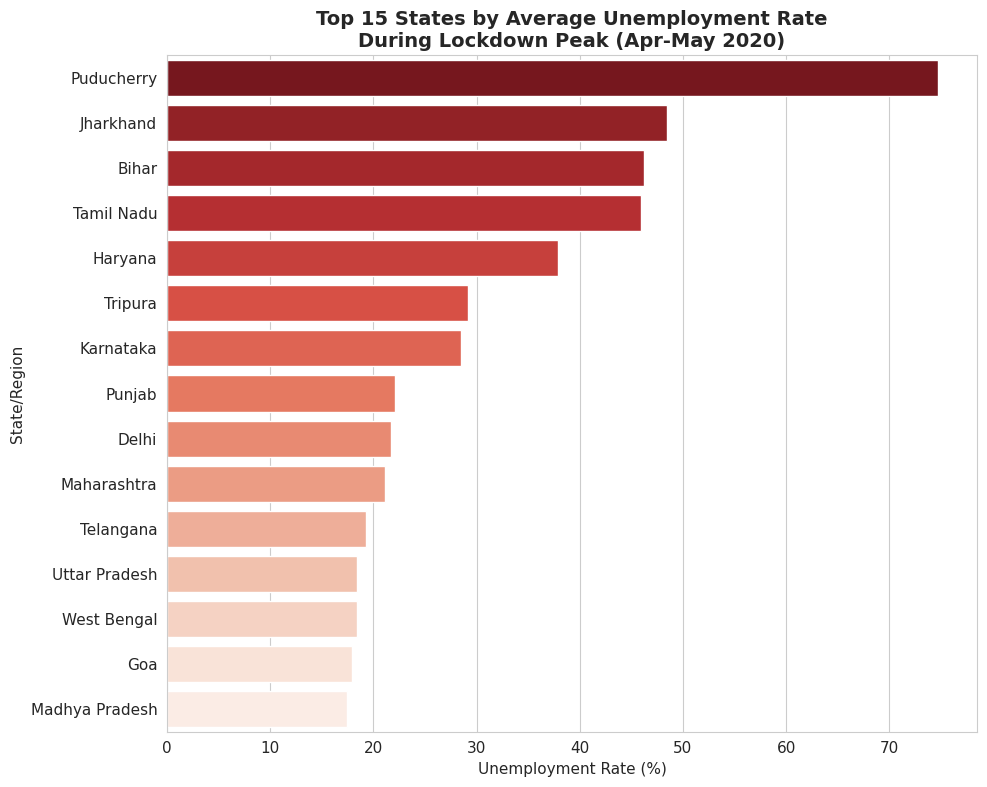

In [13]:
lockdown_peak = combined[(combined['Date']>='2020-04-01') & (combined['Date']<='2020-05-31')]
state_peak = lockdown_peak.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,8))
sns.barplot(x=state_peak.values, y=state_peak.index, palette='Reds_r')
plt.title('Top 15 States by Average Unemployment Rate\nDuring Lockdown Peak (Apr-May 2020)', fontsize=14, fontweight='bold')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('State/Region')
plt.tight_layout()
plt.savefig('images/04_state_peak_unemployment.png', dpi=150)
plt.show()


/tmp/ipykernel_603/3535545369.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_overall.values, y=state_overall.index, palette='viridis')


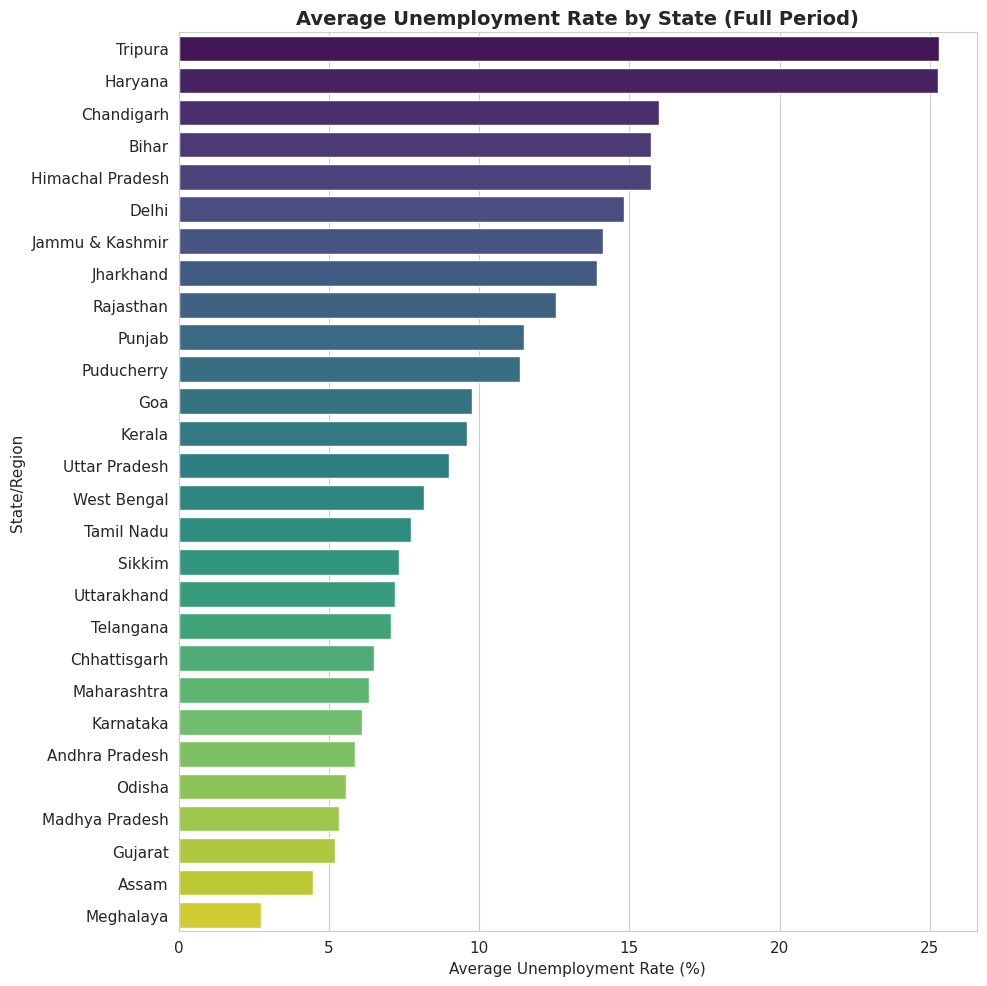

In [14]:
state_overall = combined.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,10))
sns.barplot(x=state_overall.values, y=state_overall.index, palette='viridis')
plt.title('Average Unemployment Rate by State (Full Period)', fontsize=14, fontweight='bold')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State/Region')
plt.tight_layout()
plt.savefig('images/05_state_overall_avg.png', dpi=150)
plt.show()


## 9. Zone-Wise Comparison (Dataset 2)

Dataset 2 groups states into zones (`Region2`: North, South, East, West, etc.). We
compare average unemployment across zones.


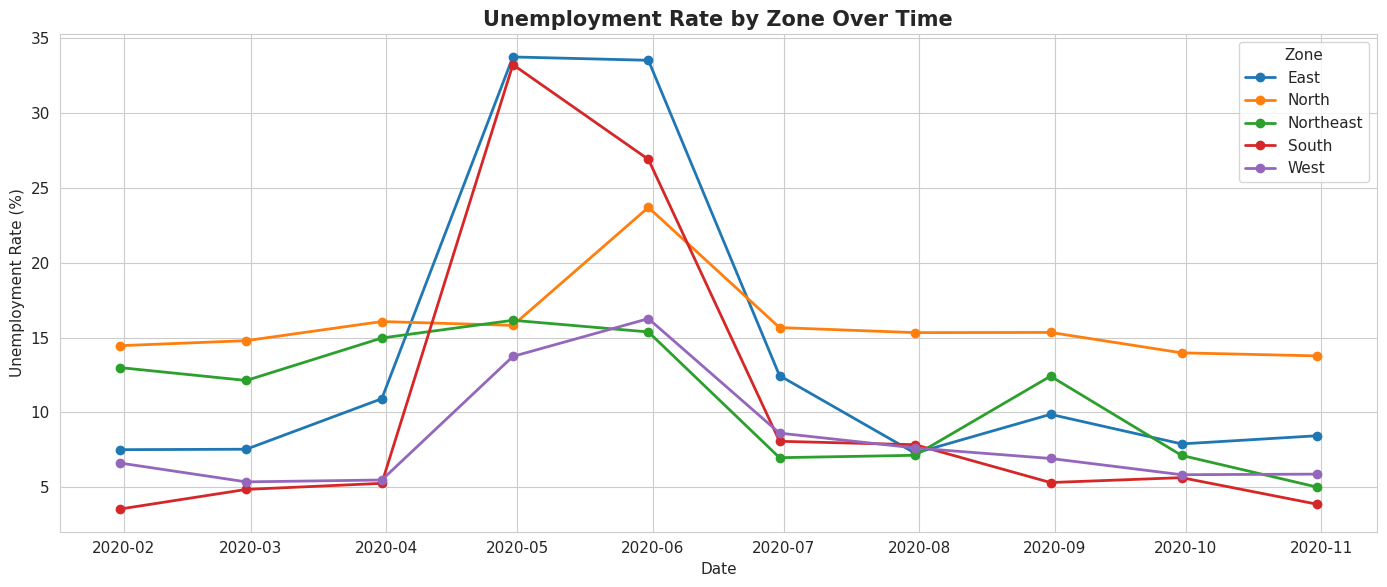

In [15]:
zone_trend = df2_clean.groupby(['Date', 'Region2'])['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14,6))
for zone, grp in zone_trend.groupby('Region2'):
    plt.plot(grp['Date'], grp['Unemployment_Rate'], marker='o', label=zone, linewidth=2)
plt.title('Unemployment Rate by Zone Over Time', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend(title='Zone')
plt.tight_layout()
plt.savefig('images/06_zone_trend.png', dpi=150)
plt.show()


## 10. Seasonal Patterns

Excluding the anomalous COVID-19 lockdown months, we look at monthly averages
(across all available years) to check for recurring seasonal unemployment patterns
(e.g. agricultural off-seasons).


/tmp/ipykernel_603/1246874382.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_labels, y=seasonal.values, palette='coolwarm')


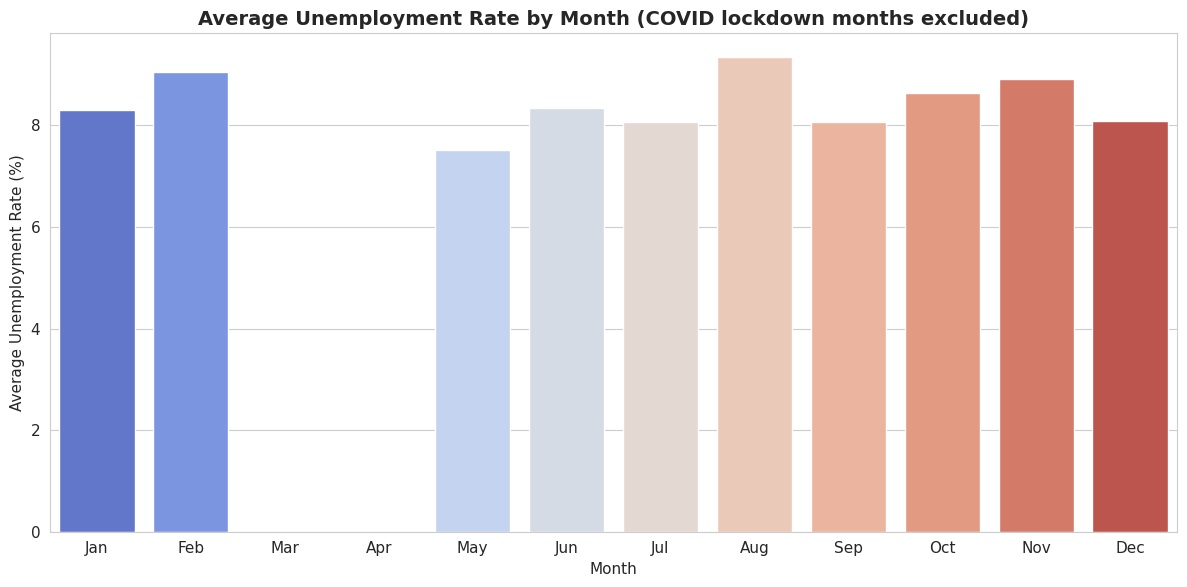

In [16]:
non_covid = combined[~((combined['Date']>='2020-03-01') & (combined['Date']<='2020-07-31'))]
seasonal = non_covid.groupby('Month')['Unemployment_Rate'].mean().reindex(range(1,13))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12,6))
sns.barplot(x=month_labels, y=seasonal.values, palette='coolwarm')
plt.title('Average Unemployment Rate by Month (COVID lockdown months excluded)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('images/07_seasonal_pattern.png', dpi=150)
plt.show()


## 11. Relationship Between Labour Participation and Unemployment

We check whether higher labour force participation correlates with unemployment rate.


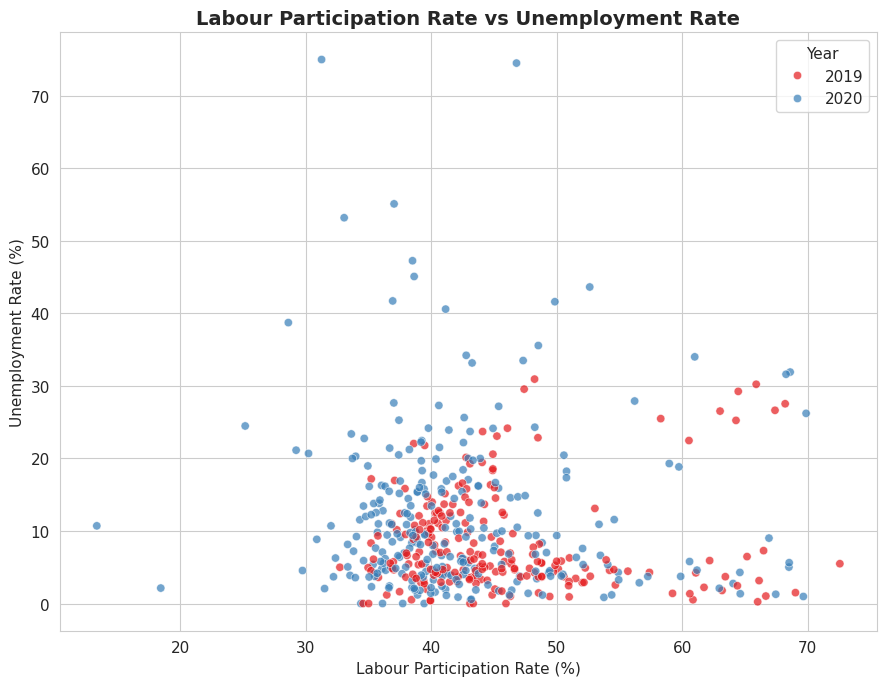

Correlation coefficient: -0.040


In [17]:
plt.figure(figsize=(9,7))
sns.scatterplot(data=combined, x='Labour_Participation_Rate', y='Unemployment_Rate', hue='Year', palette='Set1', alpha=0.7)
plt.title('Labour Participation Rate vs Unemployment Rate', fontsize=14, fontweight='bold')
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('images/08_participation_vs_unemployment.png', dpi=150)
plt.show()

corr = combined[['Labour_Participation_Rate', 'Unemployment_Rate']].corr().iloc[0,1]
print(f"Correlation coefficient: {corr:.3f}")


## 12. Correlation Heatmap

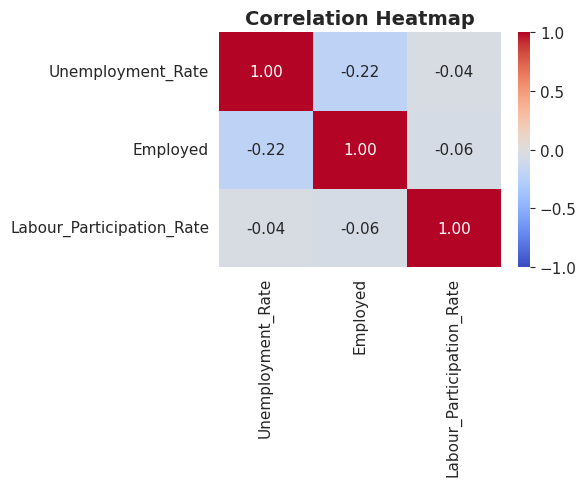

In [18]:
plt.figure(figsize=(6,5))
corr_matrix = combined[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/09_correlation_heatmap.png', dpi=150)
plt.show()


## 13. Key Insights & Policy Recommendations

**Findings:**

1. **Sharp COVID-19 spike:** The national average unemployment rate rose substantially during the March–May 2020 lockdown compared to the pre-COVID period, confirming the severe short-term economic shock of the pandemic.
2. **Urban areas hit harder:** Urban unemployment increased more sharply than rural unemployment during the lockdown, likely reflecting the greater dependence of urban workers on sectors that were shut down (retail, hospitality, construction, services) versus agriculture-linked rural livelihoods.
3. **Recovery pattern:** Unemployment rates began declining after May–June 2020 as lockdown restrictions eased, though they did not always return fully to pre-COVID levels within the observed window.
4. **State-level disparity:** A handful of states/UTs experienced unemployment rates far above the national average during the lockdown peak, suggesting the shock was geographically uneven — likely tied to differences in local industry mix (tourism, manufacturing hubs, migrant labour dependence).
5. **Zonal differences:** Regional zones show different baseline unemployment levels and different sensitivity to the pandemic shock, useful for prioritizing region-specific relief.
6. **Seasonality:** Even outside the pandemic, unemployment shows some month-to-month variation, which may relate to agricultural cycles and seasonal hiring patterns.
7. **Labour participation relationship:** The scatter plot and correlation help clarify whether states with more people actively seeking work also show higher unemployment, versus states where a large share of the population is simply outside the labour force.

**Policy implications:**
- Targeted relief and job-guarantee schemes for the worst-affected states/zones during future shocks.
- Urban employment safety nets (similar to MGNREGA for rural areas) could reduce urban unemployment volatility.
- Monitoring high-frequency (monthly) unemployment data allows faster policy response than annual statistics.
- Diversifying state economies away from single-sector dependence may reduce vulnerability to shocks like COVID-19.


## 14. Conclusion

This analysis cleaned and combined two Indian unemployment datasets spanning 2019–2020,
explored national, rural/urban, state-wise, and zonal trends, and quantified the impact
of the COVID-19 lockdown on unemployment. The lockdown period (Mar–May 2020) shows a
clear, sharp increase in unemployment across almost all regions, with urban areas and
certain states disproportionately affected. These insights can help guide targeted,
region-specific economic policy responses to similar future shocks.
